In [1]:
import sys 
sys.path.append("../")
from LCSS.LCSS_core import * 
from state import Hamiltonian, StateMachine, generate_Sright_all

In [2]:
from copy import copy
init = ["_"] * 12
p_list = np.array(["X","Y","Z"])

In [3]:
x = np.array([1,5,10,15,20,25,30,35,40,45,50])

In [4]:
l_data = []

from qiskit.quantum_info import Operator,SparsePauliOp 
def fix(s):
    out = ""
    for i in s:
        if(i=="_"):
            out+="I"
        else:
            out+=i 
    return out 

for i in range(5):
    l=[]
    
    paulis = []
    for i in range(25):
        idx = np.random.randint(0,9)
        p_idx = np.random.randint(0,3,3)
        v = np.array(copy(init))
        v[[idx,idx+1,idx+2]] = p_list[p_idx]
        paulis.append("".join(v))
    coeffs = np.random.random(len(paulis))*2 - 1
    
    H = Pauli_Hamiltonian(coeffs,paulis)    

    for n in x:
        l.append(LCSS_full(H,n)[0])
    
    o = Operator(SparsePauliOp(data = [fix(p) for p in paulis],coeffs= coeffs)).data    
    l_data.append(np.array(l)/np.linalg.eigvalsh(o)[0])


Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  8
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  8
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  8
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  8
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  8
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  8
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  8
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  8
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  8
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  8
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  10
Space Size:  8
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  6
Space Size:  4
Space Size:  2
Space Size:  8
Space Size:  6
Space Size:  4
Space Siz

In [5]:
mean = np.mean(l_data,axis=0)
std = np.std(l_data,axis=0)

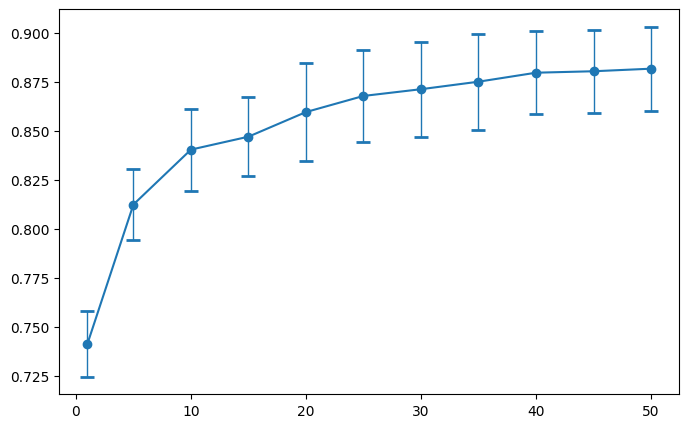

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Compute mean and standard deviation
mean = np.mean(l_data, axis=0)
std = np.std(l_data, axis=0)

# Create the plot
plt.figure(figsize=(8, 5))
plt.errorbar(x, mean, yerr=std, fmt='-o', capsize=5, capthick=2, elinewidth=1)

# Show the plot
plt.show()